In [69]:
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import datetime as dt
import xarray as xr
import os
import matplotlib as mpl
fs=10
mpl.rc('xtick', labelsize=fs)
mpl.rc('ytick', labelsize=fs)
mpl.rc('legend', fontsize=fs)
mpl.rc('axes', titlesize=fs)
mpl.rc('axes', labelsize=fs)
mpl.rc('figure', titlesize=fs)
mpl.rc('font', size=fs)
mpl.rc('font', family='sans-serif', weight='normal', style='normal')
from permetrics.regression import RegressionMetric

In [70]:
from salishsea_tools import evaltools as et

In [71]:
df = pd.read_csv('/home/jvalenti/MOAD/analysis-jose/notebooks/SHEM/eval/CitSci2025_20260702.csv',parse_dates=['datetime'],index_col=False,skiprows=[7],header=6)
df['o2uM'] = df['o2uM'].astype(float)
df['datetime'] = df['datetime'].astype('datetime64[ns]')
df = df[df['o2uM']>0]
df = df[df['depth']>0].reset_index(drop=True)

df = df.rename(columns={"latitude": "Lat", "longitude": "Lon",'datetime':'dtUTC','depth':'Z'})
df['dtUTC'] = df['dtUTC'].dt.tz_localize(None)

In [72]:
filemap={'dissolved_oxygen':'biol_T','diatoms':'biol_T','flagellates':'biol_T'}

fdict={'biol_T':1}
path = f'/data/jvalenti/results'
mask_path = '/home/jvalenti/MOAD/grid2/mesh_mask202108_TDV.nc'

start_date = dt.datetime(2025,1,1) 
end_date = dt.datetime(2025,12,31) 

In [73]:
# # data=et.matchData(df,filemap,fdict,mask_path,mod_start=start_date,mod_end=end_date,mod_basedir=path,mod_nam_fmt='SHEM')
# # data.to_csv('O2_2025_SHEM.csv')

# path = '/results2/SalishSea/nowcast-green.202111'
# filemap={'dissolved_oxygen':'chem_T','diatoms':'biol_T','flagellates':'biol_T'}
# fdict={'chem_T':1,'biol_T':1}

# data=et.matchData(df,filemap,fdict,mask_path,mod_start=start_date,mod_end=end_date,mod_basedir=path,mod_nam_fmt='nowcast')
# data.to_csv('O2_2025_20211.csv')

# # path = '/ocean/atall/MOAD/Model/202410b/oxygen/'
# # filemap={'dissolved_oxygen':'chem_T'}
# # fdict={'chem_T':24}

# # data=et.matchData(df,filemap,fdict,mask_path,mod_start=start_date,mod_end=end_date,mod_basedir=path,mod_nam_fmt='nowcast')
# # data.to_csv('O2_2024_202410.csv')

In [74]:
def calculate_rmse_bias(obs, predicted):
    """
    Calculates the Root Mean Squared Error (RMSE) between obs and predicted values.
    """
    # Calculate the squared differences
    differences_squared = (obs - predicted) ** 2
    # Calculate the mean of the squared differences (MSE)
    mean_of_differences_squared = differences_squared.mean()
    # Take the square root (RMSE)
    rmse_val = np.sqrt(mean_of_differences_squared)
    bias = (predicted - obs).mean()
    evaluator = RegressionMetric(np.array(obs), np.array(predicted))
    WI = evaluator.willmott_index()
    cor = np.corrcoef(obs, predicted)[0, 1]
    print(f"RMSE: {rmse_val}, Bias: {bias}, Willmott Index: {WI}, N: {len(obs)},Nmod: {len(predicted)}, Correlation: {cor}")
    return rmse_val, bias,WI

In [75]:
#Combine all versions in single file
data= pd.read_csv('O2_2025_SHEM.csv')
data = data.rename(columns={'mod_dissolved_oxygen':'SHEM_DO','mod_diatoms':'SHEM_diatoms','mod_flagellates':'SHEM_flagellates'})
data2= pd.read_csv('O2_2025_20211.csv')
data['SHEM_chl']=(data['SHEM_flagellates']+data['SHEM_diatoms'])*1.6
data['v202111_DO']=data2['mod_dissolved_oxygen']
data['v202111_diatoms']=data2['mod_diatoms']
data['v202111_flagellates']=data2['mod_flagellates']
data['v202111_chl']=(data['v202111_flagellates']+data['v202111_diatoms'])*1.6
data.to_csv('O2_2025_all.csv')

In [76]:
data= pd.read_csv('O2_2025_all.csv')

RMSE: 43.61819723932986, Bias: -25.59969249720892, Willmott Index: 0.8699004466949659, N: 20576,Nmod: 20576, Correlation: 0.8319937365269338
RMSE: 33.20660304006772, Bias: -0.8478498211915546, Willmott Index: 0.8939236431802972, N: 20576,Nmod: 20576, Correlation: 0.8261551759008616


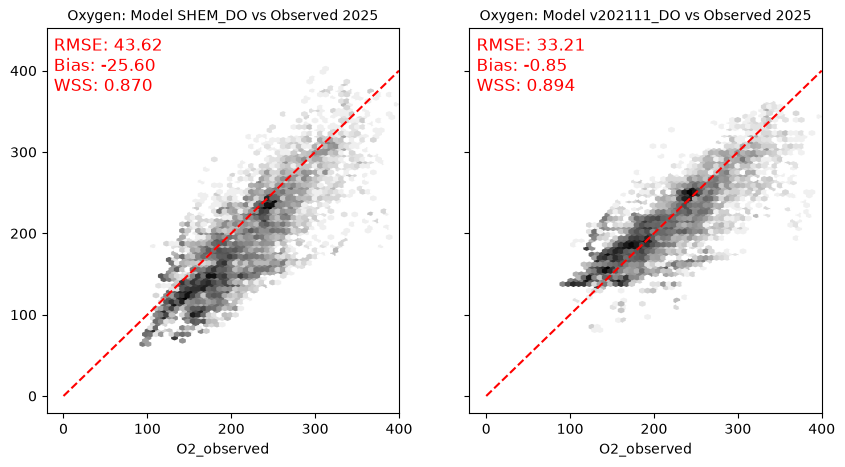

In [77]:
import matplotlib

def plot_o2(ax,data,name = "SHEM"):
    model = np.array(data[name])
    obs = np.array(data['o2uM'])
    mask_N = (obs > 0) & (~np.isnan(model))
    rmse, bias, WI = calculate_rmse_bias(obs[mask_N], model[mask_N])

    ax.hexbin(obs[mask_N], model[mask_N],gridsize=80, norm=matplotlib.colors.LogNorm(),cmap='Greys')
    ax.set_xlabel('O2_observed')
    ax.set_title(f'Oxygen: Model {name} vs Observed 2025')

    ax.plot(np.linspace(0, 400),np.linspace(0, 400),'r--')
    ax.text(0.02, 0.98,f'RMSE: {rmse:.2f}\nBias: {bias:.2f}\nWSS: {WI:.3f}',ha='left',va='top',fontsize=12,transform=ax.transAxes,color='red')
    ax.set_xlim(-20,400)

fig,axs = plt.subplots(1,2,figsize=(10,5),sharey=True)
plot_o2(axs[0],data,'SHEM_DO')
plot_o2(axs[1],data,'v202111_DO')


RMSE: 3.6688567194511323, Bias: -0.8584731395957536, Willmott Index: 0.39828767430655065, N: 20333,Nmod: 20333, Correlation: 0.43703736378212577
RMSE: 3.670390019765578, Bias: -0.8482848189858309, Willmott Index: 0.3829764260330708, N: 20333,Nmod: 20333, Correlation: 0.4430157604188929


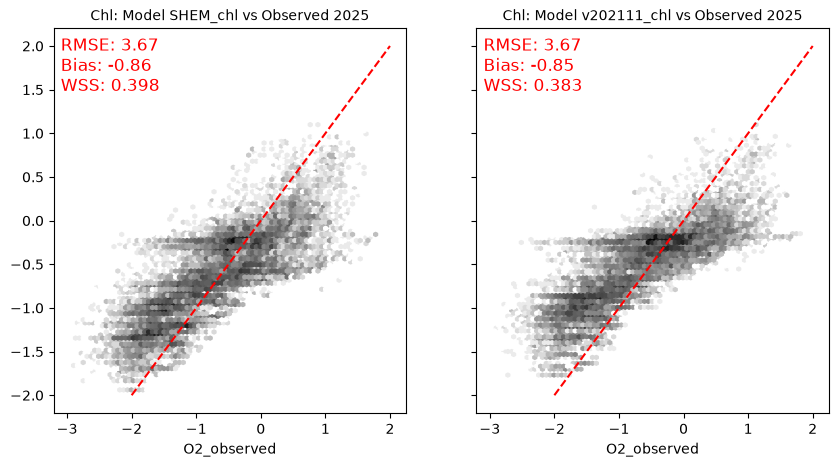

In [78]:
import matplotlib
data['chl'] = data['chl'].astype(float)

def plot_o2(ax,data,name = "SHEM"):
    model = np.array(data[name])
    obs = np.array(data['chl'])
    mask_N = (obs > 0) & (~np.isnan(model))
    rmse, bias, WI = calculate_rmse_bias(obs[mask_N], model[mask_N])

    ax.hexbin(np.log10(obs[mask_N]+0.001), np.log10(model[mask_N]+0.001),gridsize=80, norm=matplotlib.colors.LogNorm(),cmap='Greys')
    ax.set_xlabel('O2_observed')
    ax.set_title(f'Chl: Model {name} vs Observed 2025')

    ax.plot(np.linspace(-2, 2),np.linspace(-2, 2),'r--')
    ax.text(0.02, 0.98,f'RMSE: {rmse:.2f}\nBias: {bias:.2f}\nWSS: {WI:.3f}',ha='left',va='top',fontsize=12,transform=ax.transAxes,color='red')


fig,axs = plt.subplots(1,2,figsize=(10,5),sharey=True)
plot_o2(axs[0],data,'SHEM_chl')
plot_o2(axs[1],data,'v202111_chl')


RMSE: 47.49638521976315, Bias: -16.22486112824426, Willmott Index: 0.7561377923835577, N: 4548,Nmod: 4548, Correlation: 0.6136614583845974
RMSE: 28.65310592222121, Bias: 1.1325806252119452, Willmott Index: 0.8533012621462066, N: 12429,Nmod: 12429, Correlation: 0.745863289930964
RMSE: 24.86213336508897, Bias: 11.74450288959661, Willmott Index: 0.7802586564361603, N: 3599,Nmod: 3599, Correlation: 0.6820615463201577
RMSE: 53.61391336633453, Bias: -18.804371289443633, Willmott Index: 0.7351723076293692, N: 4548,Nmod: 4548, Correlation: 0.5688585084323051
RMSE: 40.35782069554238, Bias: -26.08312156211343, Willmott Index: 0.7996432814486532, N: 12429,Nmod: 12429, Correlation: 0.7568641316055199
RMSE: 40.24799396754224, Bias: -32.517331009356305, Willmott Index: 0.6658430773445427, N: 3599,Nmod: 3599, Correlation: 0.6884120628540674
RMSE: 47.49638521976315, Bias: -16.22486112824426, Willmott Index: 0.7561377923835577, N: 4548,Nmod: 4548, Correlation: 0.6136614583845974
RMSE: 28.65310592222121

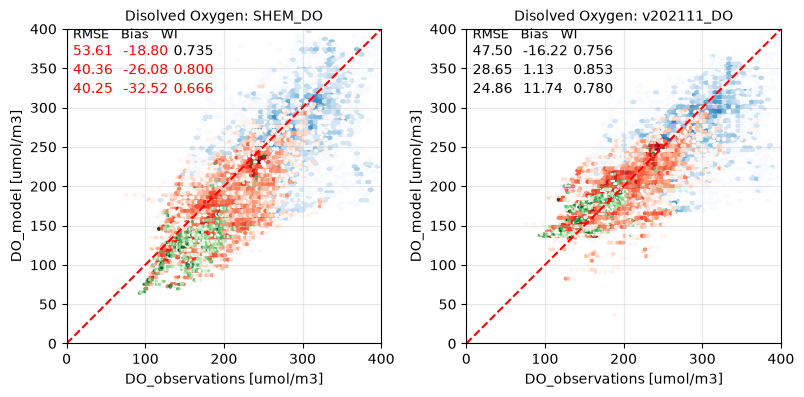

In [79]:
runs = ['SHEM_DO','v202111_DO']

colors = {"Shallow": "blue", "Intermediate": "orange", "Deep": "green"}
cmaps = {"Shallow": "Blues", "Intermediate": "Reds", "Deep": "Greens"}

depth_limits = [(0, 20), (20, 100), (100, np.inf)]
depth_labels = ["Shallow", "Intermediate", "Deep"]
tol = 0.05 #5%per

# Load once
dft = data
obs, depth = dft['o2uM'], dft['Z']

def get_stats(model, mask):
    return calculate_rmse_bias(obs[mask], model[mask]) if mask.any() else (np.nan, np.nan, np.nan)

base = dft['v202111_DO']
mask_base = (base != 0) & (~obs.isna()) & (~base.isna())
baseline_stats = [
    get_stats(base, mask_base & depth.between(dmin, dmax, inclusive='left'))
    for dmin, dmax in depth_limits
]

fig, axs = plt.subplots(4, 5, figsize=(20, 20))
axs = axs.flatten()

for i, name in enumerate(runs):
    ax = axs[i]
    model = dft[name]
    mask = (model != 0) & (~obs.isna()) & (~model.isna())

    stats = []

    for (label, (dmin, dmax)), (base_rmse, base_bias, base_wi) in zip(zip(depth_labels, depth_limits), baseline_stats):
        dm = mask & depth.between(dmin, dmax, inclusive='left')
        rmse, bias, wi = get_stats(model, dm)

        #ax.scatter(obs[dm],model[dm], color=colors[label], alpha=0.6, label=label)
        ax.hexbin(obs[dm], model[dm],gridsize=80, norm=matplotlib.colors.LogNorm(),cmap=cmaps[label])

        better_rmse = abs(rmse) <= abs(base_rmse) - abs(tol*base_rmse) 
        better_bias = abs(bias) <= abs(base_bias) - abs(tol*base_bias) 
        better_WI = wi >= base_wi + tol*base_wi 

        stats.append((rmse, bias, wi,
            "green" if better_rmse else("black" if abs(rmse) <= abs(base_rmse) + abs(tol*base_rmse) else "red") ,
            "green" if better_bias else("black" if abs(bias) <= abs(base_bias) + abs(tol*base_bias) else "red") ,
            "green" if better_WI else("black" if wi >= base_wi - tol*base_wi else "red")
        ))

    max_val = 400
    ax.plot([0, max_val], [0, max_val], 'r--')
    ax.set(xlim=(0, max_val), ylim=(0, max_val), aspect='equal',
           title=f'Disolved Oxygen: {name}', xlabel='DO_observations [umol/m3]', ylabel='DO_model [umol/m3]')

    #if i == 0:
        #ax.legend(loc=4)

    # --- Stats text ---
    ax.text(0.02, 0.97, "RMSE   Bias   WI", transform=ax.transAxes, fontsize=9)

    for k, (rmse, bias, wi, c1, c2, c3) in enumerate(stats):
        y = 0.95 - 0.06 * k
        rmse_txt = "—" if np.isnan(rmse) else f"{rmse:.2f}"
        bias_txt = "—" if np.isnan(bias) else f"{bias:.2f}"
        wi_txt = "—" if np.isnan(wi) else f"{wi:.3f}"

        ax.text(0.02, y, rmse_txt, color=c1, transform=ax.transAxes, va='top')
        ax.text(0.18, y, bias_txt, color=c2, transform=ax.transAxes, va='top')
        ax.text(0.34, y, wi_txt, color=c3, transform=ax.transAxes, va='top')

    ax.grid(alpha=0.3)

# Clean unused axes
for j in range(i + 1, len(axs)):
    fig.delaxes(axs[j])

plt.tight_layout()
plt.show()

RMSE: 0.6618873976133332, Bias: -0.3122988678303018, Willmott Index: 0.5252078809391741, N: 4546,Nmod: 4546, Correlation: 0.3049781482395564
RMSE: 0.616110872502264, Bias: 0.23869356377905357, Willmott Index: 0.6468392817838745, N: 12429,Nmod: 12429, Correlation: 0.5858225012412389
RMSE: 0.78620533601443, Bias: 0.6803858463033888, Willmott Index: 0.5118293346935943, N: 3599,Nmod: 3599, Correlation: 0.5176906778475439
RMSE: 0.6900027125781233, Bias: -0.35037129182576865, Willmott Index: 0.5315459616669719, N: 4532,Nmod: 4532, Correlation: 0.2702243712474757
RMSE: 0.5312199150889971, Bias: 0.11655838986322029, Willmott Index: 0.7129586045894749, N: 12279,Nmod: 12279, Correlation: 0.6128718575355713
RMSE: 0.6433704336139161, Bias: 0.5244970888876732, Willmott Index: 0.5650223445122294, N: 3522,Nmod: 3522, Correlation: 0.5311348828445243
RMSE: 0.6415659777778147, Bias: -0.322527410044476, Willmott Index: 0.540874111240585, N: 4532,Nmod: 4532, Correlation: 0.31843169102667207
RMSE: 0.554270

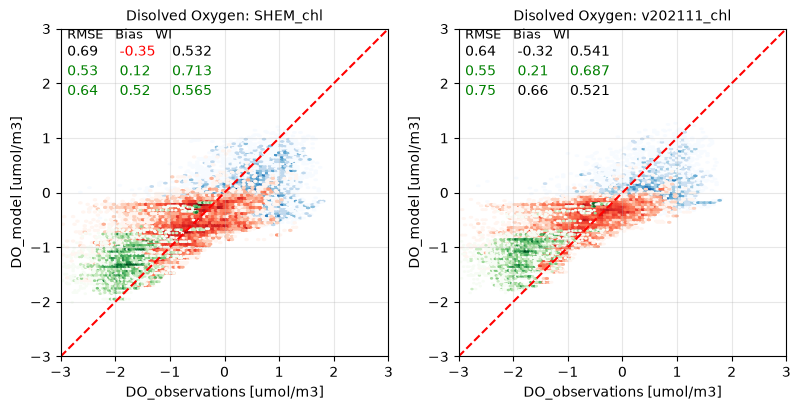

In [80]:
runs = ['SHEM_chl','v202111_chl']

colors = {"Shallow": "blue", "Intermediate": "orange", "Deep": "green"}
cmaps = {"Shallow": "Blues", "Intermediate": "Reds", "Deep": "Greens"}

depth_limits = [(0, 20), (20, 100), (100, np.inf)]
depth_labels = ["Shallow", "Intermediate", "Deep"]
tol = 0.05 #5%per

# Load once
dft = data
obs, depth = np.log10(dft['chl'] + 0.001), dft['Z']

def get_stats(model, mask):
    return calculate_rmse_bias(obs[mask], model[mask]) if mask.any() else (np.nan, np.nan, np.nan)

base = np.log10(dft['v202111_chl'] + 0.001)
mask_base = (~obs.isna()) & (~base.isna())
baseline_stats = [
    get_stats(base, mask_base & depth.between(dmin, dmax, inclusive='left'))
    for dmin, dmax in depth_limits
]

fig, axs = plt.subplots(4, 5, figsize=(20, 20))
axs = axs.flatten()

for i, name in enumerate(runs):
    ax = axs[i]
    model = dft[name]
    model = np.log10(model + 0.001)
    mask = (obs>-3) & (~model.isna())

    stats = []

    for (label, (dmin, dmax)), (base_rmse, base_bias, base_wi) in zip(zip(depth_labels, depth_limits), baseline_stats):
        dm = mask & depth.between(dmin, dmax, inclusive='left')
        rmse, bias, wi = get_stats(model, dm)

        #ax.scatter(obs[dm],model[dm], color=colors[label], alpha=0.6, label=label)
        ax.hexbin(obs[dm], model[dm],gridsize=80, norm=matplotlib.colors.LogNorm(),cmap=cmaps[label])

        better_rmse = abs(rmse) <= abs(base_rmse) - abs(tol*base_rmse) 
        better_bias = abs(bias) <= abs(base_bias) - abs(tol*base_bias) 
        better_WI = wi >= base_wi + tol*base_wi 

        stats.append((rmse, bias, wi,
            "green" if better_rmse else("black" if abs(rmse) <= abs(base_rmse) + abs(tol*base_rmse) else "red") ,
            "green" if better_bias else("black" if abs(bias) <= abs(base_bias) + abs(tol*base_bias) else "red") ,
            "green" if better_WI else("black" if wi >= base_wi - tol*base_wi else "red")
        ))

    max_val = 3
    ax.plot([-3, max_val], [-3, max_val], 'r--')
    ax.set(xlim=(-3, max_val), ylim=(-3, max_val), aspect='equal',
           title=f'Disolved Oxygen: {name}', xlabel='DO_observations [umol/m3]', ylabel='DO_model [umol/m3]')

    #if i == 0:
        #ax.legend(loc=4)

    # --- Stats text ---
    ax.text(0.02, 0.97, "RMSE   Bias   WI", transform=ax.transAxes, fontsize=9)

    for k, (rmse, bias, wi, c1, c2, c3) in enumerate(stats):
        y = 0.95 - 0.06 * k
        rmse_txt = "—" if np.isnan(rmse) else f"{rmse:.2f}"
        bias_txt = "—" if np.isnan(bias) else f"{bias:.2f}"
        wi_txt = "—" if np.isnan(wi) else f"{wi:.3f}"

        ax.text(0.02, y, rmse_txt, color=c1, transform=ax.transAxes, va='top')
        ax.text(0.18, y, bias_txt, color=c2, transform=ax.transAxes, va='top')
        ax.text(0.34, y, wi_txt, color=c3, transform=ax.transAxes, va='top')

    ax.grid(alpha=0.3)

# Clean unused axes
for j in range(i + 1, len(axs)):
    fig.delaxes(axs[j])

plt.tight_layout()
plt.show()

In [81]:
df = pd.read_csv('/home/jvalenti/MOAD/analysis-jose/notebooks/SHEM/eval/PugetSound_2025.csv',parse_dates=['Sample_Date'],index_col=False)
#df = df[df['NO23_field']>0]
df = df[df['DO_field']>0]
df = df.rename(columns={"Latitude": "Lat", "Longitude": "Lon",'Sample_Date':'dtUTC','Sample_Depth':'Z'})
df['dtUTC'] = df['dtUTC'].dt.tz_localize(None)

/tmp/ipykernel_194599/1756239542.py:1: DtypeWarning: Columns (0: DO_Qual) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('/home/jvalenti/MOAD/analysis-jose/notebooks/SHEM/eval/PugetSound_2025.csv',parse_dates=['Sample_Date'],index_col=False)


In [82]:
filemap={'dissolved_oxygen':'biol_T'}

fdict={'biol_T':1}
#path = f'/data/jvalenti/results'
path = f'/home/jvalenti/scratch/run_SHEM/results'

mask_path = '/home/jvalenti/MOAD/grid2/mesh_mask202108_TDV.nc'

start_date = dt.datetime(2025,1,1) 
end_date = dt.datetime(2025,12,31) 

In [83]:
# # data=et.matchData(df,filemap,fdict,mask_path,mod_start=start_date,mod_end=end_date,mod_basedir=path,mod_nam_fmt='SHEM')
# # data.to_csv('DO_puget_2025_SHEM.csv')

# path = '/results2/SalishSea/nowcast-green.202111'

# filemap={'dissolved_oxygen':'chem_T'}
# fdict={'chem_T':1}
# data=et.matchData(df,filemap,fdict,mask_path,mod_start=start_date,mod_end=end_date,mod_basedir=path,mod_nam_fmt='nowcast')
# data.to_csv('DO_puget_2025_20211.csv')

# # path = '/ocean/atall/MOAD/Model/202410b/oxygen/'
# # fdict={'chem_T':24}
# # data=et.matchData(df,filemap,fdict,mask_path,mod_start=start_date,mod_end=end_date,mod_basedir=path,mod_nam_fmt='nowcast')
# # data.to_csv('DO_puget_2025_202410.csv')

In [84]:
#Combine all versions in single file
data= pd.read_csv('DO_puget_2025_SHEM.csv')
data = data.rename(columns={'mod_dissolved_oxygen':'SHEM'})
data2= pd.read_csv('DO_puget_2025_20211.csv')
data['v202111']=data2['mod_dissolved_oxygen']
#data3= pd.read_csv('DO_puget_2025_202410.csv')
#data['v202410']=data3['mod_dissolved_oxygen']

data.to_csv('DO_puget_2025_all.csv')

In [85]:
data= pd.read_csv('DO_puget_2025_all.csv')

RMSE: 24.894180097016466, Bias: -11.291004253405761, Willmott Index: 0.8963173215755614, N: 118770,Nmod: 118770, Correlation: 0.8397614209023947
RMSE: 20.726365965999968, Bias: -10.497414992549983, Willmott Index: 0.9328978739232141, N: 118770,Nmod: 118770, Correlation: 0.9031583623638071


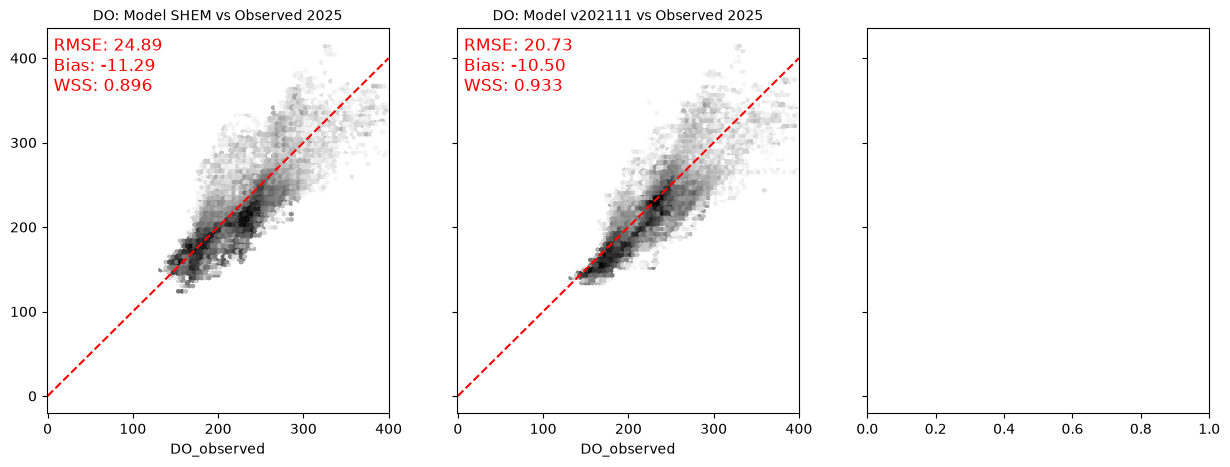

In [86]:
fig,axs = plt.subplots(1,3,figsize=(15,5),sharey=True)

def plot_NO3(ax,data,name = "SHEM"):
    model = np.array(data[name])
    obs = np.array(data['DO_field'])*31.25
    mask_N = (obs > 0) & (~np.isnan(model))
    rmse, bias, WI = calculate_rmse_bias(obs[mask_N], model[mask_N])

    ax.hexbin(obs[mask_N], model[mask_N],gridsize=80, norm=matplotlib.colors.LogNorm(),cmap='Greys')
    #ax.scatter(obs[mask_N],model[mask_N], alpha=0.6)

    ax.set_xlabel('DO_observed')
    ax.set_title(f'DO: Model {name} vs Observed 2025')

    ax.plot(np.linspace(0, 400),np.linspace(0, 400),'r--')
    ax.text(0.02, 0.98,f'RMSE: {rmse:.2f}\nBias: {bias:.2f}\nWSS: {WI:.3f}',ha='left',va='top',fontsize=12,transform=ax.transAxes,color='red')
    ax.set_xlim(-1,400)
    
plot_NO3(axs[0],data,'SHEM')
plot_NO3(axs[1],data,'v202111')

RMSE: 29.751417625509532, Bias: 2.1630300147986152, Willmott Index: 0.8969894491051651, N: 19963,Nmod: 19963, Correlation: 0.8115403641473886
RMSE: 20.491784055810587, Bias: -14.481288414140728, Willmott Index: 0.9139339737248526, N: 56976,Nmod: 56976, Correlation: 0.9131446722655561
RMSE: 15.011427779367091, Bias: -11.113113675659296, Willmott Index: 0.9430045959702904, N: 41831,Nmod: 41831, Correlation: 0.9482812433370945
RMSE: 32.99151414990289, Bias: 6.597755604949231, Willmott Index: 0.87340508579337, N: 19963,Nmod: 19963, Correlation: 0.7759386469925404
RMSE: 23.015041378115548, Bias: -14.451539965648058, Willmott Index: 0.8721990310718666, N: 56976,Nmod: 56976, Correlation: 0.8650927434538034
RMSE: 22.7740217154334, Bias: -15.523239445287944, Willmott Index: 0.8403573263872244, N: 41831,Nmod: 41831, Correlation: 0.8420777616524209
RMSE: 29.751417625509532, Bias: 2.1630300147986152, Willmott Index: 0.8969894491051651, N: 19963,Nmod: 19963, Correlation: 0.8115403641473886
RMSE: 20

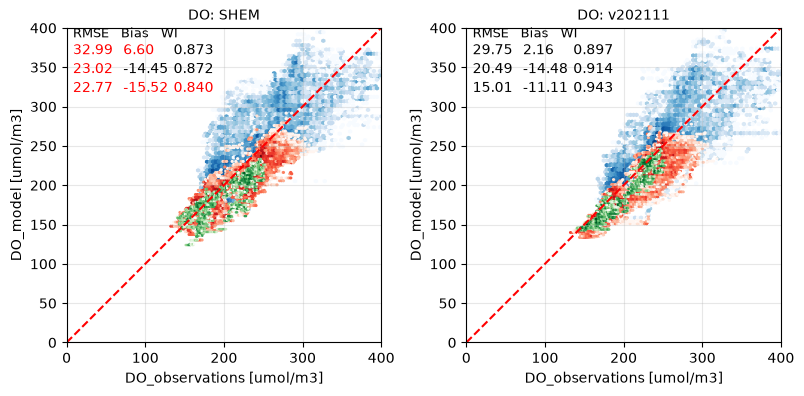

In [87]:
runs = ['SHEM','v202111']

colors = {"Shallow": "blue", "Intermediate": "orange", "Deep": "green"}
cmaps = {"Shallow": "Blues", "Intermediate": "Reds", "Deep": "Greens"}

depth_limits = [(0, 20), (20, 100), (100, np.inf)]
depth_labels = ["Shallow", "Intermediate", "Deep"]
tol = 0.05 #5%per

# Load once
dft = data
obs, depth = dft['DO_field']*31.25, dft['Z']

def get_stats(model, mask):
    return calculate_rmse_bias(obs[mask], model[mask]) if mask.any() else (np.nan, np.nan, np.nan)

base = dft['v202111']
mask_base = (base != 0) & (~obs.isna()) & (~base.isna())
baseline_stats = [
    get_stats(base, mask_base & depth.between(dmin, dmax, inclusive='left'))
    for dmin, dmax in depth_limits
]

fig, axs = plt.subplots(4, 5, figsize=(20, 20))
axs = axs.flatten()

for i, name in enumerate(runs):
    ax = axs[i]
    model = dft[name]
    mask = (model != 0) & (~obs.isna()) & (~model.isna())

    stats = []

    for (label, (dmin, dmax)), (base_rmse, base_bias, base_wi) in zip(zip(depth_labels, depth_limits), baseline_stats):
        dm = mask & depth.between(dmin, dmax, inclusive='left')
        rmse, bias, wi = get_stats(model, dm)

        #ax.scatter(obs[dm],model[dm], color=colors[label], alpha=0.6, label=label)
        ax.hexbin(obs[dm], model[dm],gridsize=80, norm=matplotlib.colors.LogNorm(),cmap=cmaps[label])

        better_rmse = abs(rmse) <= abs(base_rmse) - abs(tol*base_rmse) 
        better_bias = abs(bias) <= abs(base_bias) - abs(tol*base_bias) 
        better_WI = wi >= base_wi + tol*base_wi 

        stats.append((rmse, bias, wi,
            "green" if better_rmse else("black" if abs(rmse) <= abs(base_rmse) + abs(tol*base_rmse) else "red") ,
            "green" if better_bias else("black" if abs(bias) <= abs(base_bias) + abs(tol*base_bias) else "red") ,
            "green" if better_WI else("black" if wi >= base_wi - tol*base_wi else "red")
        ))

    max_val = 400
    ax.plot([0, max_val], [0, max_val], 'r--')
    ax.set(xlim=(0, max_val), ylim=(0, max_val), aspect='equal',
           title=f'DO: {name}', xlabel='DO_observations [umol/m3]', ylabel='DO_model [umol/m3]')

    # if i == 0:
    #     ax.legend(loc=4)

    # --- Stats text ---
    ax.text(0.02, 0.97, "RMSE   Bias   WI", transform=ax.transAxes, fontsize=9)

    for k, (rmse, bias, wi, c1, c2, c3) in enumerate(stats):
        y = 0.95 - 0.06 * k
        rmse_txt = "—" if np.isnan(rmse) else f"{rmse:.2f}"
        bias_txt = "—" if np.isnan(bias) else f"{bias:.2f}"
        wi_txt = "—" if np.isnan(wi) else f"{wi:.3f}"

        ax.text(0.02, y, rmse_txt, color=c1, transform=ax.transAxes, va='top')
        ax.text(0.18, y, bias_txt, color=c2, transform=ax.transAxes, va='top')
        ax.text(0.34, y, wi_txt, color=c3, transform=ax.transAxes, va='top')

    ax.grid(alpha=0.3)

# Clean unused axes
for j in range(i + 1, len(axs)):
    fig.delaxes(axs[j])

plt.tight_layout()
plt.show()